In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

sns.set(style="darkgrid", rc={"font.family": "serif"})
sns.set_palette("gnuplot2")

np.random.seed(123)

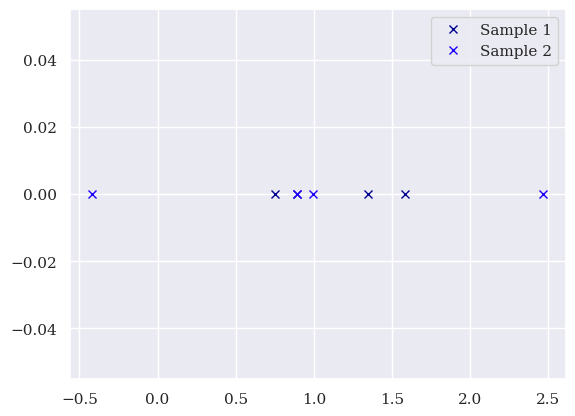

In [2]:
mu_1 = 1.25
mu_2 = 1.30

sig_1 = np.sqrt(0.11)
sig_2 = np.sqrt(0.50)

x_1 = np.random.normal(mu_1, sig_1, 4)
x_2 = np.random.normal(mu_2, sig_2, 4)

plt.figure()
plt.plot(x_1, [0, 0, 0, 0], "x", label="Sample 1")
plt.plot(x_2, [0, 0, 0, 0], "x", label="Sample 2")
plt.legend()

In [3]:
# Calculating likelihoods
def likelihood(x, mu, sig):
    return np.prod(stats.norm.pdf(x, loc=mu, scale=sig))


print(likelihood(x_1, mu_1, sig_1))
print(likelihood(x_1, mu_2, sig_2))

0.21819841326701406
0.058401551331077675


In [4]:
given_points = [1.01, 1.30, 1.35, 1.44]
L_1_gp = likelihood(given_points, mu_1, sig_1)
L_2_gp = likelihood(given_points, mu_2, sig_2)

print(L_1_gp)
print(L_2_gp)

1.2918411137616792
0.09111254560865162


In [5]:
def gauss_samples(mu, sig, n):
    return np.random.normal(mu, sig, n)


# Exercise 1

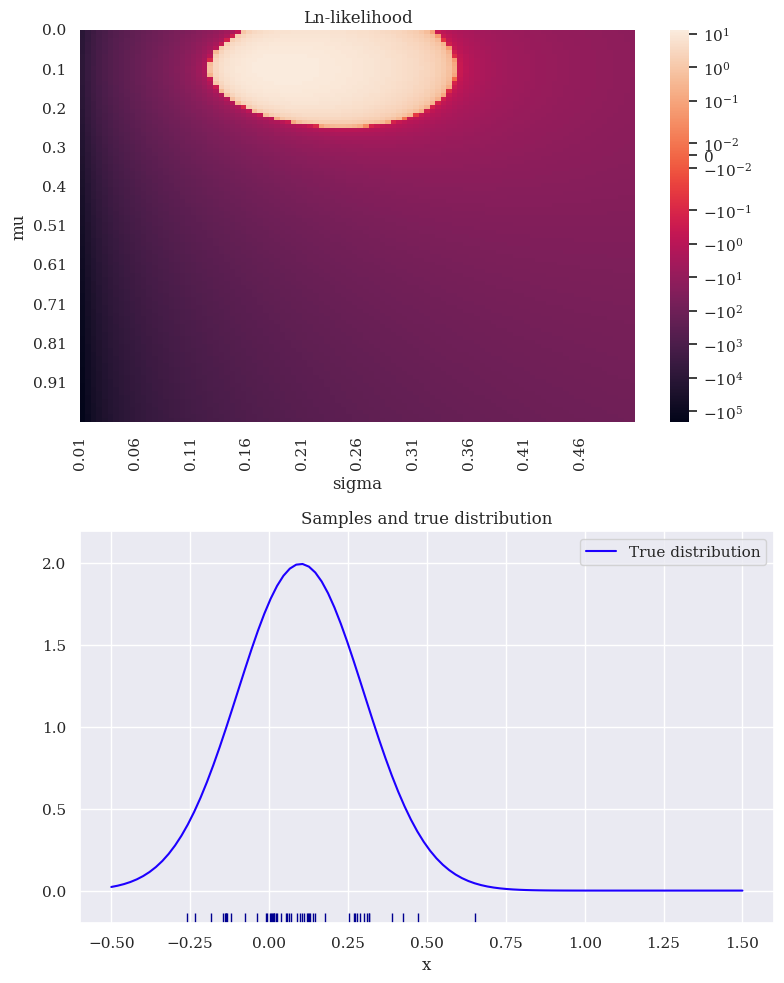

In [ ]:
mu = 0.1
sigma = 0.2
n = 50
samples = gauss_samples(mu, sigma, n)

mu_scan = np.linspace(0, 1, 100)
sigma_scan = np.linspace(0.01, 0.5, 100)
ln_L_scan = np.zeros((len(mu_scan), len(sigma_scan)))

for i, mue in enumerate(mu_scan):
    for j, sigmae in enumerate(sigma_scan):
        ln_L_scan[i, j] = np.sum(stats.norm.logpdf(samples, loc=mue, scale=sigmae))
#
fig, ax = plt.subplots(2, 1, figsize=(8, 10))
sns.heatmap(
    ln_L_scan,
    xticklabels=np.round(sigma_scan, 2),
    yticklabels=np.round(mu_scan, 2),
    ax=ax[0],
    norm=plt.matplotlib.colors.SymLogNorm(
        linthresh=0.03, vmin=ln_L_scan.min(), vmax=ln_L_scan.max()
    ),
)
step = 10
ax[0].set_xticks(np.arange(0, len(sigma_scan), step))
ax[0].set_xticklabels(np.round(sigma_scan[::step], 2))
ax[0].set_yticks(np.arange(0, len(mu_scan), step))
ax[0].set_yticklabels(np.round(mu_scan[::step], 2))
ax[0].set_xlabel("sigma")
ax[0].set_ylabel("mu")
ax[0].set_title("Ln-likelihood")

sns.rugplot(samples, ax=ax[1])
A = np.linspace(-0.5, 1.5, 100)
ax[1].plot(A, stats.norm.pdf(A, loc=mu, scale=sigma), label="True distribution")
ax[1].set_xlabel("x")
ax[1].set_title("Samples and true distribution")
ax[1].legend()
plt.tight_layout()


In [ ]:
print("Maximum ln-likelihood from scan:", ln_L_scan.max())
print("True ln-likelihood:", np.sum(stats.norm.logpdf(samples, loc=mu, scale=sigma)))
print(
    "Analytical maximum ln-likelihood:",
    np.sum(
        stats.norm.logpdf(samples, loc=np.mean(samples), scale=np.std(samples, ddof=1))
    ),
)

Maximum ln-likelihood from scan: 12.556321355807992
True ln-likelihood: 12.3569461681066
Analytical maximum ln-likelihood: 12.555805131024975


2000


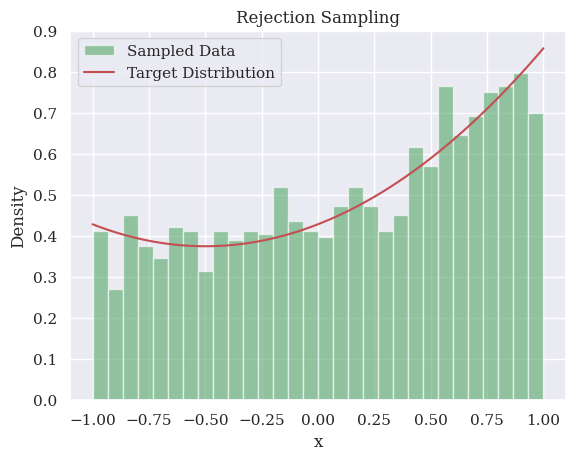

In [ ]:
func_vals = []
a_c = 0.5
b_c = 0.5
def norm_pdf(var, a, b):
    return 1/(2*(1+b/3)) * (1 + a*var + b*var**2)
while len(func_vals) < 2000:
    x = np.random.uniform(-1 , 1)
    y = np.random.uniform(0, 0.9)
    if y < norm_pdf(x, a_c, b_c):
        func_vals.append(x)

X = np.array(func_vals)
plt.hist(X, bins=30, density=True, alpha=0.6, color='g', label='Sampled Data')
A = np.linspace(-1, 1, 100)
plt.plot(A, norm_pdf(A, a_c, b_c), 'r-', label='Target Distribution')
plt.title('Rejection Sampling')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
print(len(func_vals))

In [39]:
np.savetxt("MC_ex_2_lec_3.txt", X)